#### Classification algorithms
Logistic Regression, Decision Tree, Random Forest

**Dataset:** `load_iris()`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [3]:
## displaying the feature names as well 
feature_names = iris.feature_names
f'Features {len(feature_names)}:, {feature_names}'

"Features 4:, ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']"

#### Splitting the data into training and testing sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1) Logistic regression
Model class probabilities via softmax (generalization of sigmoid).

In [12]:
logistic_reg = LogisticRegression(max_iter=1000, multi_class='auto')
logistic_reg.fit(X_train_scaled, y_train)
pred_lr = logistic_reg.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, pred_lr))

Accuracy: 0.9210526315789473


In [14]:
print(classification_report(y_test, pred_lr, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



### Confusion matrix

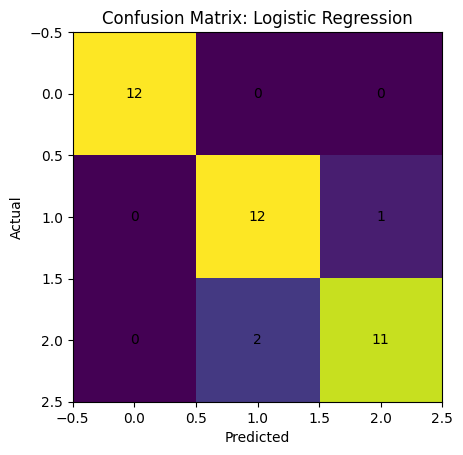

In [15]:
cm = confusion_matrix(y_test, pred_lr)
plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()

### 2) Decision Tree Classifier
Greedy splitting to maximize information gain / Gini decrease.

In [19]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
pred = tree.predict(X_test)
print('Accuracy:', accuracy_score(y_test, pred))

Accuracy: 0.9210526315789473


In [21]:
print(classification_report(y_test, pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



### confusion matrix

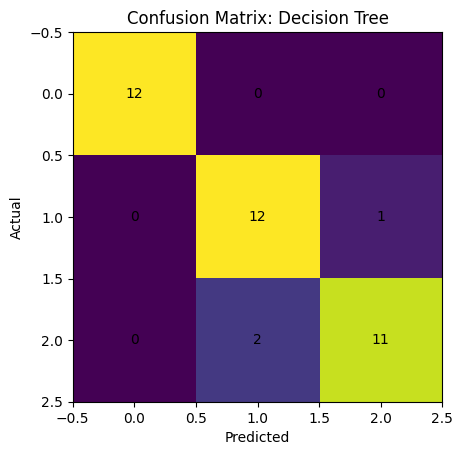

In [23]:
cm = confusion_matrix(y_test, pred)
plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()

### 3) Random forest classifier
Bagging ensemble of decision trees to reduce variance.

In [24]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, pred_rf))

Accuracy: 0.8947368421052632


In [25]:
print(classification_report(y_test, pred_rf, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



### feature importance visualization

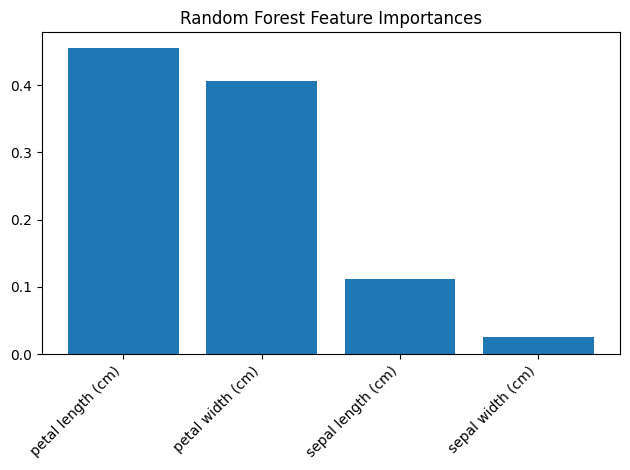

In [26]:
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
plt.figure()
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), np.array(feature_names)[idx], rotation=45, ha='right')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()